# Experiment 9: Eight-Loss Metric Learning Comparison on DINOv2 ViT-L/14

**Research Question:** Do loss functions that optimise pairwise embedding-space
similarity directly (Circle Loss, Multi-Similarity, Proxy-NCA++, Contrastive)
outperform classification-margin losses (ArcFace, CosFace, SubCenterArcFace,
Focal) on jaguar re-identification when using DINOv2 ViT-L/14 as the backbone?


## Overview

1. **Data Loading**: Stratified train/validation split (identical seed to all experiments)
2. **Backbone**: DINOv2 ViT-L/14 (frozen) — best-performing backbone from prior experiments
3. **Embedding Extraction**: Cache DINOv2 embeddings once, reuse for all 8 loss conditions
4. **Eight Loss Functions**: Train one independent model per loss, same projection head and optimiser
5. **Results**: mAP comparison, training stability, per-identity analysis
6. **Submission**: Best loss applied to test set

## Loss Functions Compared

### Classification-Margin Losses (treat re-ID as N-class classification)
| Loss | Key Mechanism |
|---|---|
| **ArcFace** | Additive angular margin on cosine logits |
| **CosFace** | Additive cosine margin (large margin softmax) |
| **SubCenterArcFace** | K sub-centres per identity — tolerates intra-class noise |
| **Focal Loss** | Down-weights easy examples via modulating factor (1−p)^γ |

### Metric Learning Losses (optimise pairwise similarity directly)
| Loss | Key Mechanism |
|---|---|
| **Circle Loss** | Per-score adaptive weighting — hard pairs get larger gradients |
| **Multi-Similarity Loss** | Three-signal pair mining (self, neg-relative, pos-relative) |
| **Proxy-NCA++** | Learnable proxy per identity — stable on small imbalanced sets |
| **Contrastive (hard mining)** | Classical positive/negative pair loss with semi-hard mining |

## Controlled Variables (Same Across ALL Eight Conditions)
- Backbone: **DINOv2 ViT-L/14** (frozen, 1024-dim output)
- Projection head: Linear(1024 → 512 → 256), BatchNorm, ReLU, Dropout(0.3)
- Embedding dim: 256 (all losses work in the same space)
- Optimizer: AdamW (lr=1e-4, weight_decay=1e-4)
- Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
- Epochs: 50, Patience: 10, Batch size: 32, Seed: 42, Val split: 0.2


## 1. Setup and Configuration

In [24]:
import os
import math
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from torchvision import transforms
from PIL import Image
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import wandb
from kaggle_secrets import UserSecretsClient

# Secrets
user_secrets = UserSecretsClient()
os.environ["HF_TOKEN"]      = user_secrets.get_secret("hf_api")
os.environ["WANDB_API_KEY"] = user_secrets.get_secret("wandb_api")

# Reproducibility
RANDOM_SEED = 42

def set_seed(seed: int) -> None:
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device:  {device}")
print(f"PyTorch: {torch.__version__}  |  timm: {timm.__version__}")


Device:  cuda
PyTorch: 2.9.0+cu126  |  timm: 1.0.24


In [25]:
RANDOM_SEED = 42

# Eight loss conditions
LOSS_CONFIGS = [
    # Classification-margin family
    {
        "name":        "01_ArcFace",
        "loss_family": "classification",
        "description": "Additive angular margin on cosine logits",
        "color":       "steelblue",
    },
    {
        "name":        "02_CosFace",
        "loss_family": "classification",
        "description": "Additive cosine margin (large margin softmax)",
        "color":       "cornflowerblue",
    },
    {
        "name":        "03_SubCenterArcFace",
        "loss_family": "classification",
        "description": "K sub-centres per identity — tolerates intra-class noise",
        "color":       "royalblue",
    },
    {
        "name":        "04_FocalLoss",
        "loss_family": "classification",
        "description": "Down-weights easy examples via (1−p)^gamma modulation",
        "color":       "navy",
    },
    # Metric learning family
    {
        "name":        "05_CircleLoss",
        "loss_family": "metric",
        "description": "Per-score adaptive weighting — hard pairs get larger gradients",
        "color":       "coral",
    },
    {
        "name":        "06_MultiSimilarity",
        "loss_family": "metric",
        "description": "Three-signal pair mining (self, neg-relative, pos-relative)",
        "color":       "tomato",
    },
    {
        "name":        "07_ProxyNCA",
        "loss_family": "metric",
        "description": "Learnable proxy per identity — stable on small imbalanced sets",
        "color":       "firebrick",
    },
    {
        "name":        "08_Contrastive",
        "loss_family": "metric",
        "description": "Positive/negative pair loss with semi-hard mining",
        "color":       "darkred",
    },
]

config = {
    # Paths
    "data_dir":       Path("/kaggle/input/competitions/jaguar-re-id"),
    "checkpoint_dir": Path("/kaggle/working/checkpoints"),
    "cache_dir":      Path("/kaggle/working/embeddings"),

    # Backbone (frozen)
    "dinov2_model": "vit_large_patch14_dinov2.lvd142m",
    "input_size":   518,   # DINOv2 ViT-L native resolution

    # Projection head (identical for all losses)
    "embedding_dim": 256,
    "hidden_dim":    512,
    "dropout":       0.3,

    # ArcFace / CosFace / SubCenter hyperparams
    "arcface_margin":    0.5,
    "arcface_scale":     64.0,
    "cosface_margin":    0.35,
    "cosface_scale":     64.0,
    "subcenter_k":       3,       # sub-centres per identity

    # Focal loss
    "focal_gamma":       2.0,

    # Circle loss
    "circle_m":          0.25,    # margin
    "circle_gamma":      64,      # scale (lowered: 256 overflows float32)

    # Multi-Similarity loss
    "ms_alpha":          2.0,
    "ms_beta":           50.0,
    "ms_base":           0.5,
    "ms_epsilon":        0.1,

    # Proxy-NCA++ temperature
    "proxy_temperature": 0.1,

    # Contrastive loss
    "contrastive_margin": 1.0,

    # Training (identical for all conditions)
    "batch_size":      32,
    "learning_rate":   1e-4,
    "weight_decay":    1e-4,
    "num_epochs":      50,
    "patience":        10,
    "val_split":       0.2,
    "seed":            RANDOM_SEED,
}

config["checkpoint_dir"].mkdir(parents=True, exist_ok=True)
config["cache_dir"].mkdir(parents=True, exist_ok=True)

print("Eight-Loss DINOv2 Configuration:")
print(f"  Backbone:    {config['dinov2_model']}  (input: {config['input_size']}px)")
print(f"  Embedding:   {config['embedding_dim']}-dim (all losses)")
print(f"  Batch size:  {config['batch_size']}, Epochs: {config['num_epochs']}")
print()
for lc in LOSS_CONFIGS:
    fam = "margin" if lc['loss_family'] == "classification" else "metric"
    print(f"  {fam}  [{lc['name']}]  {lc['description']}")


Eight-Loss DINOv2 Configuration:
  Backbone:    vit_large_patch14_dinov2.lvd142m  (input: 518px)
  Embedding:   256-dim (all losses)
  Batch size:  32, Epochs: 50

  margin  [01_ArcFace]  Additive angular margin on cosine logits
  margin  [02_CosFace]  Additive cosine margin (large margin softmax)
  margin  [03_SubCenterArcFace]  K sub-centres per identity — tolerates intra-class noise
  margin  [04_FocalLoss]  Down-weights easy examples via (1−p)^gamma modulation
  metric  [05_CircleLoss]  Per-score adaptive weighting — hard pairs get larger gradients
  metric  [06_MultiSimilarity]  Three-signal pair mining (self, neg-relative, pos-relative)
  metric  [07_ProxyNCA]  Learnable proxy per identity — stable on small imbalanced sets
  metric  [08_Contrastive]  Positive/negative pair loss with semi-hard mining


In [26]:
wandb.login()

True

In [27]:
wandb.init(
    project=os.getenv("WANDB_PROJECT", "jaguar-reid-iota"),
    config={
        "experiment":        "loss-comparison-dinov2",
        "backbone":          config["dinov2_model"],
        "input_size":        config["input_size"],
        "losses":            [lc["name"] for lc in LOSS_CONFIGS],
        "embedding_dim":     config["embedding_dim"],
        "hidden_dim":        config["hidden_dim"],
        "dropout":           config["dropout"],
        "batch_size":        config["batch_size"],
        "learning_rate":     config["learning_rate"],
        "weight_decay":      config["weight_decay"],
        "num_epochs":        config["num_epochs"],
        "patience":          config["patience"],
        "val_split":         config["val_split"],
        "seed":              config["seed"],
        # Loss-specific hyperparams
        "arcface_margin":    config["arcface_margin"],
        "cosface_margin":    config["cosface_margin"],
        "subcenter_k":       config["subcenter_k"],
        "focal_gamma":       config["focal_gamma"],
        "circle_m":          config["circle_m"],
        "circle_gamma":      config["circle_gamma"],
        "ms_alpha":          config["ms_alpha"],
        "ms_beta":           config["ms_beta"],
        "proxy_temperature": config["proxy_temperature"],
        "contrastive_margin":config["contrastive_margin"],
    },
    name="loss-comparison-dinov2",
)
print("W&B run initialised: loss-comparison-dinov2  (single run, 8 conditions)")
print("  Per-loss metrics  → {loss_name}/")
print("  Final comparison  → results/")


W&B run initialised: loss-comparison-dinov2  (single run, 8 conditions)
  Per-loss metrics  → {loss_name}/
  Final comparison  → results/


## 2. Load and Prepare Data

Total images:      1895
Unique identities: 31
Min: 13  Max: 183  Mean: 61.1


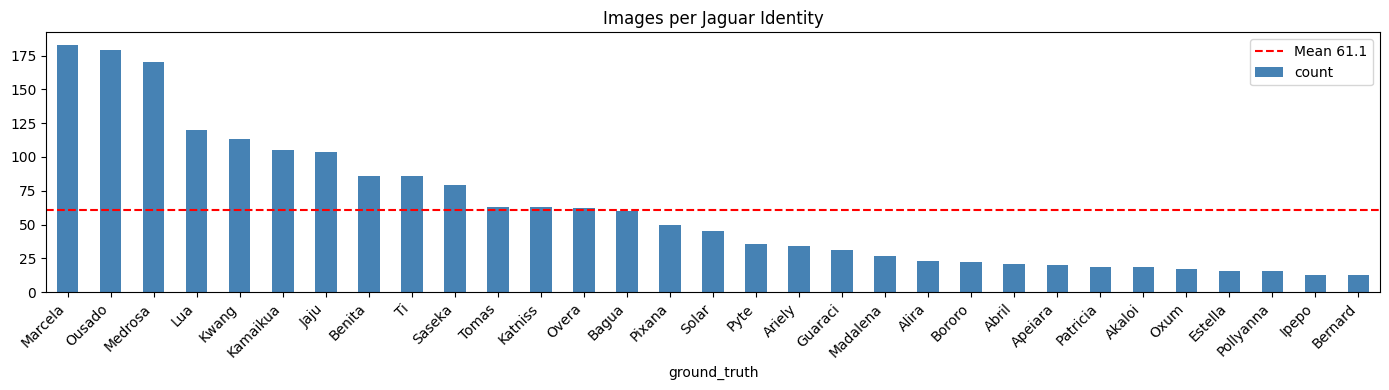

In [28]:
train_df = pd.read_csv(config["data_dir"] / "train.csv")
print(f"Total images:      {len(train_df)}")
print(f"Unique identities: {train_df['ground_truth'].nunique()}")

identity_counts = train_df['ground_truth'].value_counts()
print(f"Min: {identity_counts.min()}  Max: {identity_counts.max()}  "
      f"Mean: {identity_counts.mean():.1f}")

fig, ax = plt.subplots(figsize=(14, 4))
identity_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(identity_counts.mean(), color='red', linestyle='--',
           label=f'Mean {identity_counts.mean():.1f}')
ax.set_title('Images per Jaguar Identity'); ax.legend()
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
wandb.log({"identity_distribution": wandb.Image(fig)}); plt.show()


In [29]:
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

train_data, val_data = train_test_split(
    train_df, test_size=config["val_split"],
    random_state=config["seed"], stratify=train_df['ground_truth'])

assert set(train_data['ground_truth'].unique()) ==        set(val_data['ground_truth'].unique()), "Identity mismatch in split!"

train_labels_enc = train_data['label_encoded'].values
val_labels_enc   = label_encoder.transform(val_data['ground_truth'].values)
val_labels_str   = val_data['ground_truth'].values

train_paths = [config["data_dir"] / "train/train" / fn
               for fn in train_data["filename"].astype(str)]
val_paths   = [config["data_dir"] / "train/train" / fn
               for fn in val_data["filename"].astype(str)]

print(f"Train: {len(train_data)}  |  Val: {len(val_data)}  |  Classes: {num_classes}")
print("All identities in both sets ✓")
wandb.log({"num_identities": num_classes, "train_samples": len(train_data),
           "val_samples": len(val_data)})


Train: 1516  |  Val: 379  |  Classes: 31
All identities in both sets ✓


## 3. Load DINOv2 ViT-L/14 and Extract Embeddings

DINOv2 ViT-L/14 (trained via self-supervised DINO v2 on LVD-142M) produces
1024-dimensional CLS token embeddings. It was identified as the best-performing
backbone in prior experiments.

The backbone is **fully frozen** throughout — only the projection head is trained.
Embeddings are extracted once and cached to disk, then reused for all 8 loss
conditions.


In [30]:
print(f"Loading DINOv2 ViT-L/14: {config['dinov2_model']}")
dinov2 = timm.create_model(
    config["dinov2_model"],
    pretrained  = True,
    num_classes = 0,
    img_size    = config["input_size"],
)
dinov2.eval()
for p in dinov2.parameters():
    p.requires_grad = False
dinov2.to(device)

with torch.no_grad():
    dummy    = torch.randn(1, 3, config["input_size"],
                           config["input_size"]).to(device)
    dinov2_dim = dinov2(dummy).shape[1]

print(f"  Output dim:  {dinov2_dim}")
print(f"  Parameters:  {sum(p.numel() for p in dinov2.parameters()):,}")
print(f"  Frozen:      True")

preprocess = transforms.Compose([
    transforms.Resize((config["input_size"], config["input_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


Loading DINOv2 ViT-L/14: vit_large_patch14_dinov2.lvd142m
  Output dim:  1024
  Parameters:  304,367,616
  Frozen:      True


In [31]:
@torch.no_grad()
def extract_embeddings(model, image_paths, batch_size=32, desc="Extracting"):
    model.eval(); all_embs = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc=desc):
        paths   = image_paths[i:i + batch_size]; tensors = []
        for p in paths:
            try:    tensors.append(preprocess(Image.open(p).convert("RGB")))
            except: tensors.append(torch.zeros(3, config["input_size"],
                                               config["input_size"]))
        all_embs.append(
            model(torch.stack(tensors).to(device)).cpu().numpy())
    return np.vstack(all_embs)


tr_cache = config["cache_dir"] / "dinov2_train_embeddings.npz"
va_cache = config["cache_dir"] / "dinov2_val_embeddings.npz"

if tr_cache.exists():
    train_embeddings = np.load(tr_cache)["embeddings"]
    print(f"Loaded cached train embeddings: {train_embeddings.shape}")
else:
    train_embeddings = extract_embeddings(
        dinov2, train_paths, config["batch_size"], "DINOv2 train")
    np.savez_compressed(tr_cache, embeddings=train_embeddings)
    print(f"Saved train: {train_embeddings.shape}")

if va_cache.exists():
    val_embeddings = np.load(va_cache)["embeddings"]
    print(f"Loaded cached val embeddings:   {val_embeddings.shape}")
else:
    val_embeddings = extract_embeddings(
        dinov2, val_paths, config["batch_size"], "DINOv2 val")
    np.savez_compressed(va_cache, embeddings=val_embeddings)
    print(f"Saved val: {val_embeddings.shape}")


Loaded cached train embeddings: (1516, 1024)
Loaded cached val embeddings:   (379, 1024)


## 4. Shared Projection Head

In [32]:
class EmbeddingProjection(nn.Module):
    """
    Linear(D → hidden) → BN → ReLU → Dropout → Linear(hidden → emb) → BN.
    Identical for all 8 loss conditions.
    """
    def __init__(self, input_dim, hidden_dim=512,
                 output_dim=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.BatchNorm1d(output_dim),
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='relu')
                if m.bias is not None: nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x): return self.net(x)

    def get_embeddings(self, x):
        return F.normalize(self.net(x), p=2, dim=1)


# Sanity check
_p = EmbeddingProjection(dinov2_dim, config["hidden_dim"],
                          config["embedding_dim"]).to(device)
_x = torch.randn(4, dinov2_dim).to(device)
print(f"Projection head: {dinov2_dim} → {config['hidden_dim']} "
      f"→ {config['embedding_dim']}")
print(f"  Output shape: {_p(_x).shape}")
print(f"  Params: {sum(p.numel() for p in _p.parameters()):,}")
del _p, _x


Projection head: 1024 → 512 → 256
  Output shape: torch.Size([4, 256])
  Params: 657,664


## 5. Loss Function Implementations

### Classification-Margin Family
All four use a linear classification head on top of the projected embedding.
The head is discarded at inference — only the embedding space is used.

### Metric Learning Family
These losses operate directly on the embedding vectors without a classification
head. The model forward pass returns only the projected embedding.


In [33]:
# CLASSIFICATION-MARGIN LOSSES

class ArcFaceHead(nn.Module):
    """Additive Angular Margin (ArcFace)."""    
    def __init__(self, emb_dim, num_classes, margin=0.5, scale=64.0):
        super().__init__()
        self.scale = scale
        self.cos_m = math.cos(margin); self.sin_m = math.sin(margin)
        self.th    = math.cos(math.pi - margin)
        self.mm    = math.sin(math.pi - margin) * margin
        self.W     = nn.Parameter(torch.FloatTensor(num_classes, emb_dim))
        nn.init.xavier_uniform_(self.W)

    def forward(self, emb, labels):
        emb_n = F.normalize(emb, p=2, dim=1)
        w_n   = F.normalize(self.W, p=2, dim=1)
        cos   = torch.clamp(F.linear(emb_n, w_n), -1, 1)
        sin   = (1 - cos**2).clamp(min=1e-12).sqrt()
        phi   = cos * self.cos_m - sin * self.sin_m
        phi   = torch.where(cos > self.th, phi, cos - self.mm)
        oh    = torch.zeros_like(cos).scatter_(1, labels.view(-1,1).long(), 1)
        return (oh * phi + (1-oh) * cos) * self.scale


class CosFaceHead(nn.Module):
    """Large Margin Cosine Loss (CosFace)."""    
    def __init__(self, emb_dim, num_classes, margin=0.35, scale=64.0):
        super().__init__()
        self.scale = scale; self.margin = margin
        self.W = nn.Parameter(torch.FloatTensor(num_classes, emb_dim))
        nn.init.xavier_uniform_(self.W)

    def forward(self, emb, labels):
        emb_n = F.normalize(emb, p=2, dim=1)
        w_n   = F.normalize(self.W, p=2, dim=1)
        cos   = torch.clamp(F.linear(emb_n, w_n), -1, 1)
        oh    = torch.zeros_like(cos).scatter_(1, labels.view(-1,1).long(), 1)
        phi   = cos - self.margin
        return (oh * phi + (1-oh) * cos) * self.scale


class SubCenterArcFaceHead(nn.Module):
    """Sub-Center ArcFace — K sub-centres per class absorb intra-class noise."""    
    def __init__(self, emb_dim, num_classes, K=3, margin=0.5, scale=64.0):
        super().__init__()
        self.scale = scale; self.K = K
        self.cos_m = math.cos(margin); self.sin_m = math.sin(margin)
        self.th    = math.cos(math.pi - margin)
        self.mm    = math.sin(math.pi - margin) * margin
        # Shape: (num_classes * K, emb_dim)
        self.W = nn.Parameter(torch.FloatTensor(num_classes * K, emb_dim))
        nn.init.xavier_uniform_(self.W)
        self.num_classes = num_classes

    def forward(self, emb, labels):
        emb_n = F.normalize(emb, p=2, dim=1)
        w_n   = F.normalize(self.W, p=2, dim=1)
        # (B, num_classes * K)
        cos_all = torch.clamp(F.linear(emb_n, w_n), -1, 1)
        # Take max cosine over K sub-centres per class → (B, num_classes)
        cos = cos_all.view(-1, self.num_classes, self.K).max(dim=2)[0]
        sin = (1 - cos**2).clamp(min=1e-12).sqrt()
        phi = cos * self.cos_m - sin * self.sin_m
        phi = torch.where(cos > self.th, phi, cos - self.mm)
        oh  = torch.zeros_like(cos).scatter_(1, labels.view(-1,1).long(), 1)
        return (oh * phi + (1-oh) * cos) * self.scale


class FocalLoss(nn.Module):
    """Focal Loss — down-weights easy examples via (1-p)^gamma."""    
    def __init__(self, gamma=2.0, reduction='mean'):
        super().__init__()
        self.gamma = gamma; self.reduction = reduction

    def forward(self, logits, labels):
        ce   = F.cross_entropy(logits, labels, reduction='none')
        pt   = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean() if self.reduction == 'mean' else loss.sum()


print("Classification-margin losses defined: ArcFace, CosFace, "
      "SubCenterArcFace, FocalLoss ✓")


Classification-margin losses defined: ArcFace, CosFace, SubCenterArcFace, FocalLoss ✓


In [34]:
# METRIC LEARNING LOSSES

class CircleLoss(nn.Module):
    """
    Circle Loss (Sun et al., CVPR 2020).
    Numerically stable: gamma=64, clamped logits, softplus formulation.
    """
    def __init__(self, m: float = 0.25, gamma: float = 64):
        super().__init__()
        self.m     = m
        self.gamma = gamma
        self.Op    = 1 + m      # optimal similarity for positives
        self.On    = -m         # optimal similarity for negatives
        self.Dp    = 1 - m      # decision boundary for positives
        self.Dn    = m          # decision boundary for negatives

    def forward(self, embeddings: torch.Tensor, labels: torch.Tensor):
        emb  = F.normalize(embeddings, p=2, dim=1)
        sim  = emb @ emb.T          # (B, B) cosine similarities
        B    = labels.size(0)
        eye  = torch.eye(B, dtype=torch.bool, device=sim.device)
        same = (labels.unsqueeze(0) == labels.unsqueeze(1)) & ~eye
        diff = ~same & ~eye

        total_loss = torch.tensor(0.0, device=sim.device)
        count = 0

        for i in range(B):
            pos_sims = sim[i][same[i]]
            neg_sims = sim[i][diff[i]]
            if pos_sims.numel() == 0 or neg_sims.numel() == 0:
                continue
            # Weighting coefficients (detached — adaptive, not trained)
            ap = torch.clamp(self.Op - pos_sims.detach(), min=0)
            an = torch.clamp(neg_sims.detach() - self.On, min=0)
            # Log-sum-exp formulation
            logit_p = -self.gamma * ap * (pos_sims - self.Dp)
            logit_n =  self.gamma * an * (neg_sims - self.Dn)
            # Clamp logits before logsumexp to prevent float32 overflow
            logit_p = torch.clamp(logit_p, -100.0, 100.0)
            logit_n = torch.clamp(logit_n, -100.0, 100.0)
            # softplus(a+b) = log1p(exp(a)*exp(b)) but numerically stable
            lse_p  = torch.logsumexp(logit_p, dim=0)
            lse_n  = torch.logsumexp(logit_n, dim=0)
            loss_i = F.softplus(lse_n + lse_p)
            total_loss = total_loss + loss_i
            count += 1

        return total_loss / max(count, 1)


class MultiSimilarityLoss(nn.Module):
    """
    Multi-Similarity Loss (Wang et al., CVPR 2019).
    Mines pairs using three signals: self-similarity, positive-relative
    similarity, negative-relative similarity.
    """
    def __init__(self, alpha=2.0, beta=50.0, base=0.5, epsilon=0.1):
        super().__init__()
        self.alpha   = alpha
        self.beta    = beta
        self.base    = base
        self.epsilon = epsilon

    def forward(self, embeddings: torch.Tensor, labels: torch.Tensor):
        emb = F.normalize(embeddings, p=2, dim=1)
        sim = emb @ emb.T
        B   = labels.size(0)
        eye = torch.eye(B, dtype=torch.bool, device=sim.device)
        same = (labels.unsqueeze(0) == labels.unsqueeze(1)) & ~eye
        diff = ~same & ~eye

        total_loss = torch.tensor(0.0, device=sim.device)
        count = 0

        for i in range(B):
            pos_s = sim[i][same[i]]
            neg_s = sim[i][diff[i]]
            if pos_s.numel() == 0 or neg_s.numel() == 0:
                continue

            max_neg = neg_s.max().item()
            min_pos = pos_s.min().item()

            # Mine hard positives and negatives
            hard_pos = pos_s[pos_s < max_neg + self.epsilon]
            hard_neg = neg_s[neg_s > min_pos - self.epsilon]
            if hard_pos.numel() == 0: hard_pos = pos_s
            if hard_neg.numel() == 0: hard_neg = neg_s

            pos_loss = (1/self.alpha) * torch.log(
                1 + torch.sum(torch.exp(-self.alpha * (hard_pos - self.base))))
            neg_loss = (1/self.beta)  * torch.log(
                1 + torch.sum(torch.exp( self.beta  * (hard_neg - self.base))))

            total_loss = total_loss + pos_loss + neg_loss
            count += 1

        return total_loss / max(count, 1)


class ProxyNCALoss(nn.Module):
    """
    Proxy-NCA++ (Teh et al., ICCV 2019).
    One learnable proxy per class. Optimises the probability that each
    embedding is closer to its class proxy than all others.
    Stable on small imbalanced datasets — no pair mining needed.
    """
    def __init__(self, num_classes: int, emb_dim: int, temperature: float = 0.1):
        super().__init__()
        self.temperature = temperature
        self.proxies     = nn.Parameter(
            F.normalize(torch.randn(num_classes, emb_dim), p=2, dim=1))

    def forward(self, embeddings: torch.Tensor, labels: torch.Tensor):
        emb     = F.normalize(embeddings, p=2, dim=1)
        proxies = F.normalize(self.proxies, p=2, dim=1)
        # Cosine similarity to all proxies (B, num_classes)
        sim     = emb @ proxies.T / self.temperature
        return F.cross_entropy(sim, labels)


class ContrastiveLoss(nn.Module):
    """
    Contrastive Loss with semi-hard negative mining.
    For each anchor, mines:
      - all positives (same identity, exclude self)
      - semi-hard negatives: d_neg > d_pos (harder than easy, not too hard)
    """
    def __init__(self, margin: float = 1.0):
        super().__init__()
        self.margin = margin

    def forward(self, embeddings: torch.Tensor, labels: torch.Tensor):
        emb  = F.normalize(embeddings, p=2, dim=1)
        # Pairwise squared Euclidean distance
        dot  = emb @ emb.T
        sq_n = (emb**2).sum(dim=1, keepdim=True)
        dist = torch.clamp(sq_n + sq_n.T - 2*dot, min=1e-12).sqrt()

        B    = labels.size(0)
        eye  = torch.eye(B, dtype=torch.bool, device=dist.device)
        same = (labels.unsqueeze(0) == labels.unsqueeze(1)) & ~eye
        diff = ~same & ~eye

        total_loss = torch.tensor(0.0, device=dist.device)
        count = 0

        for i in range(B):
            pos_d = dist[i][same[i]]
            neg_d = dist[i][diff[i]]
            if pos_d.numel() == 0 or neg_d.numel() == 0:
                continue
            # Positive loss: pull positives together
            pos_loss = pos_d.mean()
            # Semi-hard negative: neg farther than mean pos but within margin
            mean_pos = pos_d.mean().item()
            semi_hard = neg_d[(neg_d > mean_pos) &
                               (neg_d < mean_pos + self.margin)]
            if semi_hard.numel() == 0:
                semi_hard = neg_d  # fallback to all negatives
            neg_loss = torch.clamp(self.margin - semi_hard, min=0).mean()
            total_loss = total_loss + pos_loss + neg_loss
            count += 1

        return total_loss / max(count, 1)


print("Metric learning losses defined: CircleLoss, MultiSimilarityLoss, "
      "ProxyNCALoss, ContrastiveLoss ✓")


Metric learning losses defined: CircleLoss, MultiSimilarityLoss, ProxyNCALoss, ContrastiveLoss ✓


## 6. Model Factory and Training Utilities

In [35]:
def build_model_and_criterion(loss_name: str, input_dim: int,
                               num_classes: int, cfg: dict):
    """
    Return (projection_head, criterion, extra_params) for the given loss.
    extra_params: additional trainable parameters beyond the projection head
                  (e.g. classification head weights, proxy vectors).
    """
    proj = EmbeddingProjection(
        input_dim, cfg["hidden_dim"], cfg["embedding_dim"], cfg["dropout"])
    emb_dim = cfg["embedding_dim"]

    if loss_name == "01_ArcFace":
        head      = ArcFaceHead(emb_dim, num_classes,
                                 cfg["arcface_margin"], cfg["arcface_scale"])
        criterion = nn.CrossEntropyLoss()
        extra     = list(head.parameters())
        def forward_fn(emb, labels, proj=proj, head=head, crit=criterion):
            z      = proj(emb)
            logits = head(z, labels)
            return crit(logits, labels), z
        return proj, forward_fn, extra

    elif loss_name == "02_CosFace":
        head      = CosFaceHead(emb_dim, num_classes,
                                 cfg["cosface_margin"], cfg["cosface_scale"])
        criterion = nn.CrossEntropyLoss()
        extra     = list(head.parameters())
        def forward_fn(emb, labels, proj=proj, head=head, crit=criterion):
            z      = proj(emb)
            logits = head(z, labels)
            return crit(logits, labels), z
        return proj, forward_fn, extra

    elif loss_name == "03_SubCenterArcFace":
        head      = SubCenterArcFaceHead(emb_dim, num_classes,
                                          cfg["subcenter_k"],
                                          cfg["arcface_margin"],
                                          cfg["arcface_scale"])
        criterion = nn.CrossEntropyLoss()
        extra     = list(head.parameters())
        def forward_fn(emb, labels, proj=proj, head=head, crit=criterion):
            z      = proj(emb)
            logits = head(z, labels)
            return crit(logits, labels), z
        return proj, forward_fn, extra

    elif loss_name == "04_FocalLoss":
        head      = ArcFaceHead(emb_dim, num_classes,
                                 cfg["arcface_margin"], cfg["arcface_scale"])
        criterion = FocalLoss(gamma=cfg["focal_gamma"])
        extra     = list(head.parameters())
        def forward_fn(emb, labels, proj=proj, head=head, crit=criterion):
            z      = proj(emb)
            logits = head(z, labels)
            return crit(logits, labels), z
        return proj, forward_fn, extra

    elif loss_name == "05_CircleLoss":
        criterion = CircleLoss(m=cfg["circle_m"], gamma=cfg["circle_gamma"])
        def forward_fn(emb, labels, proj=proj, crit=criterion):
            z = proj(emb)
            return crit(z, labels), z
        return proj, forward_fn, []

    elif loss_name == "06_MultiSimilarity":
        criterion = MultiSimilarityLoss(
            alpha=cfg["ms_alpha"], beta=cfg["ms_beta"],
            base=cfg["ms_base"],   epsilon=cfg["ms_epsilon"])
        def forward_fn(emb, labels, proj=proj, crit=criterion):
            z = proj(emb)
            return crit(z, labels), z
        return proj, forward_fn, []

    elif loss_name == "07_ProxyNCA":
        criterion = ProxyNCALoss(num_classes, emb_dim,
                                  cfg["proxy_temperature"])
        extra     = list(criterion.parameters())
        def forward_fn(emb, labels, proj=proj, crit=criterion):
            z = proj(emb)
            return crit(z, labels), z
        return proj, forward_fn, extra

    elif loss_name == "08_Contrastive":
        criterion = ContrastiveLoss(margin=cfg["contrastive_margin"])
        def forward_fn(emb, labels, proj=proj, crit=criterion):
            z = proj(emb)
            return crit(z, labels), z
        return proj, forward_fn, []

    else:
        raise ValueError(f"Unknown loss: {loss_name}")


print("build_model_and_criterion factory defined ✓")


build_model_and_criterion factory defined ✓


In [36]:
class EmbeddingDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels     = torch.LongTensor(labels)
    def __len__(self):          return len(self.labels)
    def __getitem__(self, idx): return self.embeddings[idx], self.labels[idx]


def _map_from_embeddings(emb, labels):
    """Identity-balanced mAP from an (N, D) embedding matrix."""    
    emb = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)
    sim = emb @ emb.T; np.fill_diagonal(sim, -1)
    id_aps = defaultdict(list)
    for q in range(len(labels)):
        ql       = labels[q]
        is_match = (labels == ql).astype(int); is_match[q] = 0
        n_pos    = is_match.sum()
        if n_pos == 0: continue
        order    = np.argsort(-sim[q]); sm = is_match[order]
        cum      = np.cumsum(sm); prec = cum / np.arange(1, len(sm)+1)
        id_aps[ql].append(float(np.sum(prec * sm) / n_pos))
    return float(np.mean([np.mean(v) for v in id_aps.values()]))


def compute_val_map(proj, val_embeddings, val_labels_str, device):
    proj.eval()
    with torch.no_grad():
        emb = proj.get_embeddings(
            torch.FloatTensor(val_embeddings).to(device)).cpu().numpy()
    return _map_from_embeddings(emb, val_labels_str)


def train_one_epoch(proj, forward_fn, loader, optimizer, device):
    proj.train()
    total_loss, total = 0.0, 0
    pbar = tqdm(loader, desc='Train', leave=False)
    for emb, labels in pbar:
        emb, labels = emb.to(device), labels.to(device)
        loss, _     = forward_fn(emb, labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item(); total += labels.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    return total_loss / len(loader)


def validate_one_epoch(proj, forward_fn, loader, device):
    proj.eval(); total_loss = 0.0
    with torch.no_grad():
        for emb, labels in loader:
            emb, labels = emb.to(device), labels.to(device)
            loss, _     = forward_fn(emb, labels)
            total_loss += loss.item()
    return total_loss / len(loader)


print("Training utilities defined ✓")


Training utilities defined ✓


## 7. Training Loop — All Eight Loss Conditions

Each condition trains an **independent model** from the same random seed,
on the same pre-extracted DINOv2 embeddings, with identical hyperparameters.
Best checkpoint saved to `/kaggle/working/checkpoints/{loss_name}_best.pth`.


In [37]:
train_dataset = EmbeddingDataset(train_embeddings, train_labels_enc)
val_dataset   = EmbeddingDataset(val_embeddings,   val_labels_enc)
train_loader  = DataLoader(train_dataset, batch_size=config["batch_size"],
                            shuffle=True,  num_workers=0, drop_last=True)
val_loader    = DataLoader(val_dataset,   batch_size=config["batch_size"],
                            shuffle=False, num_workers=0)

all_results  = {}   # loss_name -> result dict
all_val_embs = {}   # loss_name -> fine-tuned val embeddings

for lc in LOSS_CONFIGS:
    lname = lc["name"]
    ckpt_path = config["checkpoint_dir"] / f"{lname}_best.pth"

    print("\n" + "="*70)
    print(f"  {lname}  |  {lc['description']}")
    print("="*70)

    # Build model for this condition
    set_seed(config["seed"])
    proj, forward_fn, extra_params = build_model_and_criterion(
        lname, dinov2_dim, num_classes, config)
    proj.to(device)
    # Move any extra params (heads, proxies) to device
    for p in extra_params:
        if hasattr(p, 'data'): p.data = p.data.to(device)

    all_params = list(proj.parameters()) + extra_params
    optimizer  = torch.optim.AdamW(all_params,
                                    lr=config["learning_rate"],
                                    weight_decay=config["weight_decay"])
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5)

    history = {k: [] for k in
               ['train_loss', 'val_loss', 'val_map', 'lr']}
    best_val_loss    = float('inf')
    best_map         = 0.0
    best_epoch       = 0
    patience_counter = 0

    # Save epoch-0 checkpoint immediately so file ALWAYS exists,
    # even if every epoch produces NaN loss.
    torch.save({
        'epoch': 0, 'proj_state': proj.state_dict(),
        'val_loss': float('inf'), 'val_map': 0.0,
        'loss_name': lname, 'dinov2_dim': dinov2_dim,
        'num_classes': num_classes,
        'config': {k: str(v) if isinstance(v, Path) else v
                   for k, v in config.items()},
    }, ckpt_path)

    for epoch in range(config["num_epochs"]):
        tr_loss = train_one_epoch(proj, forward_fn, train_loader,
                                   optimizer, device)
        va_loss = validate_one_epoch(proj, forward_fn, val_loader, device)
        va_map  = compute_val_map(proj, val_embeddings,
                                   val_labels_str, device)
        scheduler.step(va_loss)
        lr = optimizer.param_groups[0]['lr']

        for k, v in zip(['train_loss','val_loss','val_map','lr'],
                         [tr_loss, va_loss, va_map, lr]):
            history[k].append(v)

        wandb.log({
            f"{lname}/epoch":      epoch + 1,
            f"{lname}/train_loss": tr_loss,
            f"{lname}/val_loss":   va_loss,
            f"{lname}/val_map":    va_map,
            f"{lname}/lr":         lr,
        })

        print(f"  Epoch {epoch+1:3d}/{config['num_epochs']} | "
              f"TrLoss:{tr_loss:.4f} VaLoss:{va_loss:.4f} "
              f"VamAP:{va_map:.4f} LR:{lr:.2e}")

        # NaN-safe checkpoint logic
        loss_ok     = (va_loss == va_loss)   # False when NaN
        map_better  = va_map > best_map
        loss_better = loss_ok and (va_loss < best_val_loss)

        if loss_better or map_better:
            if loss_ok:
                best_val_loss = va_loss
            best_map         = va_map
            best_epoch       = epoch + 1
            patience_counter = 0
            torch.save({
                'epoch':        best_epoch,
                'proj_state':   proj.state_dict(),
                'val_loss':     float(best_val_loss),
                'val_map':      float(best_map),
                'loss_name':    lname,
                'dinov2_dim':   dinov2_dim,
                'num_classes':  num_classes,
                'config':       {k: str(v) if isinstance(v, Path) else v
                                 for k, v in config.items()},
            }, ckpt_path)
            print(f"    ✓ Saved (epoch {best_epoch}, mAP={best_map:.4f})")
        else:
            if not loss_ok:
                print(f"    [WARN] NaN loss at epoch {epoch+1} — skipping")
            else:
                patience_counter += 1
                if patience_counter >= config['patience']:
                    print(f"  Early stopping at epoch {epoch+1}")
                    break

    # Reload best checkpoint
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    proj.load_state_dict(ckpt['proj_state'])
    proj.eval()
    for p in proj.parameters(): p.requires_grad = False

    # Fine-tuned val embeddings
    with torch.no_grad():
        ft_emb = proj.get_embeddings(
            torch.FloatTensor(val_embeddings).to(device)).cpu().numpy()
    all_val_embs[lname] = ft_emb

    # Per-identity AP
    ft_norm = ft_emb / (np.linalg.norm(ft_emb, axis=1, keepdims=True) + 1e-12)
    sim_mat = ft_norm @ ft_norm.T; np.fill_diagonal(sim_mat, -1)
    pid_ap  = defaultdict(list)
    for q in range(len(val_labels_str)):
        ql       = val_labels_str[q]
        is_match = (val_labels_str == ql).astype(int); is_match[q] = 0
        n_pos    = is_match.sum()
        if n_pos == 0: continue
        order    = np.argsort(-sim_mat[q]); sm = is_match[order]
        cum      = np.cumsum(sm); prec = cum / np.arange(1, len(sm)+1)
        pid_ap[ql].append(float(np.sum(prec * sm) / n_pos))
    per_id_ap = {k: float(np.mean(v)) for k, v in pid_ap.items()}

    all_results[lname] = {
        'best_map':   best_map,
        'best_epoch': best_epoch,
        'history':    history,
        'per_id_ap':  per_id_ap,
        'family':     lc['loss_family'],
        'description':lc['description'],
        'color':      lc['color'],
        'ckpt_path':  str(ckpt_path),
    }
    wandb.log({f"{lname}/best_val_map": best_map,
               f"{lname}/best_epoch":   best_epoch})
    print(f"\n  ✓ {lname}: best_map={best_map:.4f} @ epoch {best_epoch}")

print("\n" + "="*70)
print("ALL 8 CONDITIONS COMPLETE")
print("="*70)
for name, r in all_results.items():
    print(f"  {name:35s} | mAP: {r['best_map']:.4f} | Epoch: {r['best_epoch']}")



  01_ArcFace  |  Additive angular margin on cosine logits


Train:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch   1/50 | TrLoss:35.9587 VaLoss:30.7693 VamAP:0.3602 LR:1.00e-04
    ✓ Saved (epoch 1, mAP=0.3602)


Train:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch   2/50 | TrLoss:30.4949 VaLoss:25.3519 VamAP:0.3854 LR:1.00e-04
    ✓ Saved (epoch 2, mAP=0.3854)


...

  Epoch  48/50 | TrLoss:0.4368 VaLoss:0.3944 VamAP:0.6098 LR:1.00e-04
    ✓ Saved (epoch 48, mAP=0.6098)


Train:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch  49/50 | TrLoss:0.4301 VaLoss:0.3903 VamAP:0.6174 LR:1.00e-04
    ✓ Saved (epoch 49, mAP=0.6174)


Train:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch  50/50 | TrLoss:0.4187 VaLoss:0.3864 VamAP:0.6146 LR:1.00e-04
    ✓ Saved (epoch 50, mAP=0.6146)

  ✓ 08_Contrastive: best_map=0.6146 @ epoch 50

ALL 8 CONDITIONS COMPLETE
  01_ArcFace                          | mAP: 0.8267 | Epoch: 48
  02_CosFace                          | mAP: 0.8172 | Epoch: 50
  03_SubCenterArcFace                 | mAP: 0.7652 | Epoch: 50
  04_FocalLoss                        | mAP: 0.8259 | Epoch: 50
  05_CircleLoss                       | mAP: 0.7349 | Epoch: 50
  06_MultiSimilarity                  | mAP: 0.7096 | Epoch: 50
  07_ProxyNCA                         | mAP: 0.8270 | Epoch: 50
  08_Contrastive                      | mAP: 0.6146 | Epoch: 50


## 8. Results Summary

In [38]:
sorted_results = sorted(all_results.items(), key=lambda x: -x[1]['best_map'])
best_name, best_r = sorted_results[0]

# Identify best within each family
best_margin = max(
    [(n, r) for n, r in all_results.items() if r['family'] == 'classification'],
    key=lambda x: x[1]['best_map'])
best_metric = max(
    [(n, r) for n, r in all_results.items() if r['family'] == 'metric'],
    key=lambda x: x[1]['best_map'])

print("=" * 72)
print(f"{'Loss':35s} | {'mAP':>6} | {'Family':14s} | Epoch")
print("-" * 72)
for name, r in sorted_results:
    marker = "  << BEST"   if name == best_name else ""
    fam    = "margin"   if r['family'] == 'classification' else "metric"
    print(f"  {name:33s} | {r['best_map']:.4f} | {fam:14s} | "
          f"{r['best_epoch']:>5}{marker}")
print("=" * 72)

# Family-level summary
print(f"\nBest classification-margin: {best_margin[0]}  "
      f"(mAP={best_margin[1]['best_map']:.4f})")
print(f"Best metric learning:        {best_metric[0]}  "
      f"(mAP={best_metric[1]['best_map']:.4f})")
print(f"\nOverall winner: {best_name}  (mAP={best_r['best_map']:.4f})")

family_gain = best_metric[1]['best_map'] - best_margin[1]['best_map']
print(f"Metric vs margin best gap:   {family_gain:+.4f}")

wandb.log({
    "results/best_loss":         best_name,
    "results/best_map":          best_r['best_map'],
    "results/best_margin_map":   best_margin[1]['best_map'],
    "results/best_metric_map":   best_metric[1]['best_map'],
    "results/metric_vs_margin":  family_gain,
})


Loss                                |    mAP | Family         | Epoch
------------------------------------------------------------------------
  07_ProxyNCA                       | 0.8270 | metric         |    50  << BEST
  01_ArcFace                        | 0.8267 | margin         |    48
  04_FocalLoss                      | 0.8259 | margin         |    50
  02_CosFace                        | 0.8172 | margin         |    50
  03_SubCenterArcFace               | 0.7652 | margin         |    50
  05_CircleLoss                     | 0.7349 | metric         |    50
  06_MultiSimilarity                | 0.7096 | metric         |    50
  08_Contrastive                    | 0.6146 | metric         |    50

Best classification-margin: 01_ArcFace  (mAP=0.8267)
Best metric learning:        07_ProxyNCA  (mAP=0.8270)

Overall winner: 07_ProxyNCA  (mAP=0.8270)
Metric vs margin best gap:   +0.0003


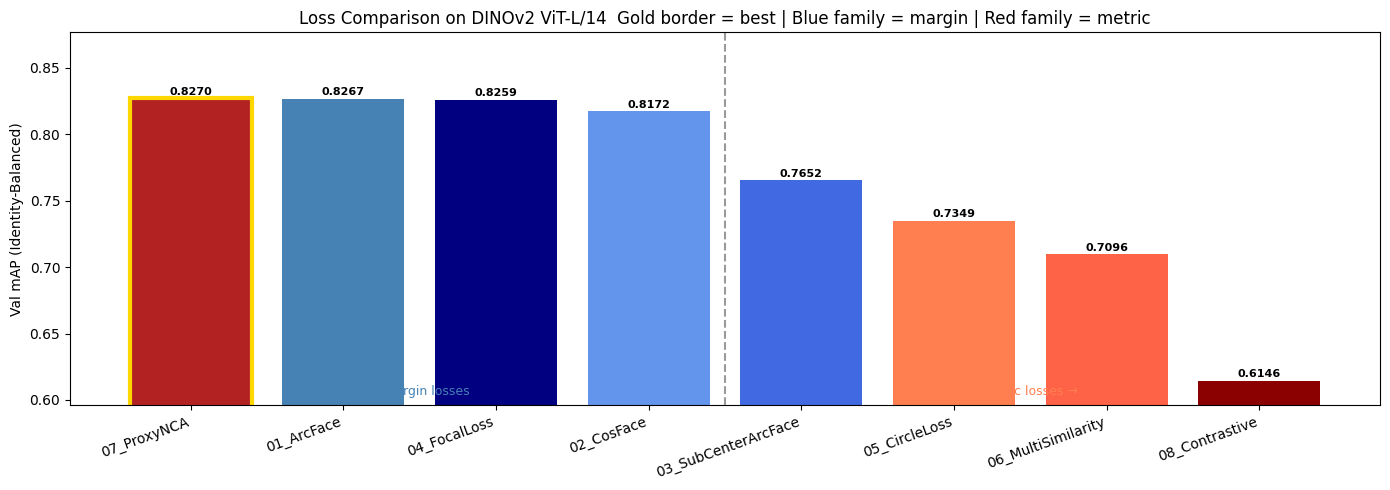

In [39]:
from matplotlib.transforms import blended_transform_factory

names  = [n for n, _ in sorted_results]
maps   = [r['best_map'] for _, r in sorted_results]
colors = [r['color']    for _, r in sorted_results]
edge   = ['gold' if n == best_name else 'none' for n in names]
lwidth = [3.0    if n == best_name else 0.0    for n in names]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(names, maps, color=colors, edgecolor=edge, linewidth=lwidth)

for bar, val, n in zip(bars, maps, names):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f"{val:.4f}", ha='center', va='bottom',
            fontsize=8, fontweight='bold')

# Family separator
n_margin = sum(1 for _, r in all_results.items()
               if r['family'] == 'classification')

trans = blended_transform_factory(ax.transData, ax.transAxes)

ax.axvline(x=n_margin - 0.5, color='black', linestyle='--',
           alpha=0.4, linewidth=1.5)
ax.text(n_margin / 2 - 0.5, 0.02,
        '← Margin losses', ha='center', fontsize=9,
        color='steelblue', transform=trans, va='bottom')
ax.text(n_margin + (len(names) - n_margin) / 2 - 0.5, 0.02,
        'Metric losses →', ha='center', fontsize=9,
        color='coral', transform=trans, va='bottom')

ax.set_ylabel('Val mAP (Identity-Balanced)')
ax.set_title('Loss Comparison on DINOv2 ViT-L/14  '
             'Gold border = best | Blue family = margin | Red family = metric')
ax.set_ylim(min(maps) * 0.97, max(maps) * 1.06)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
wandb.log({"results/loss_comparison_bar": wandb.Image(fig)})
plt.savefig(config['checkpoint_dir'] / 'loss_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 9. Training Curves

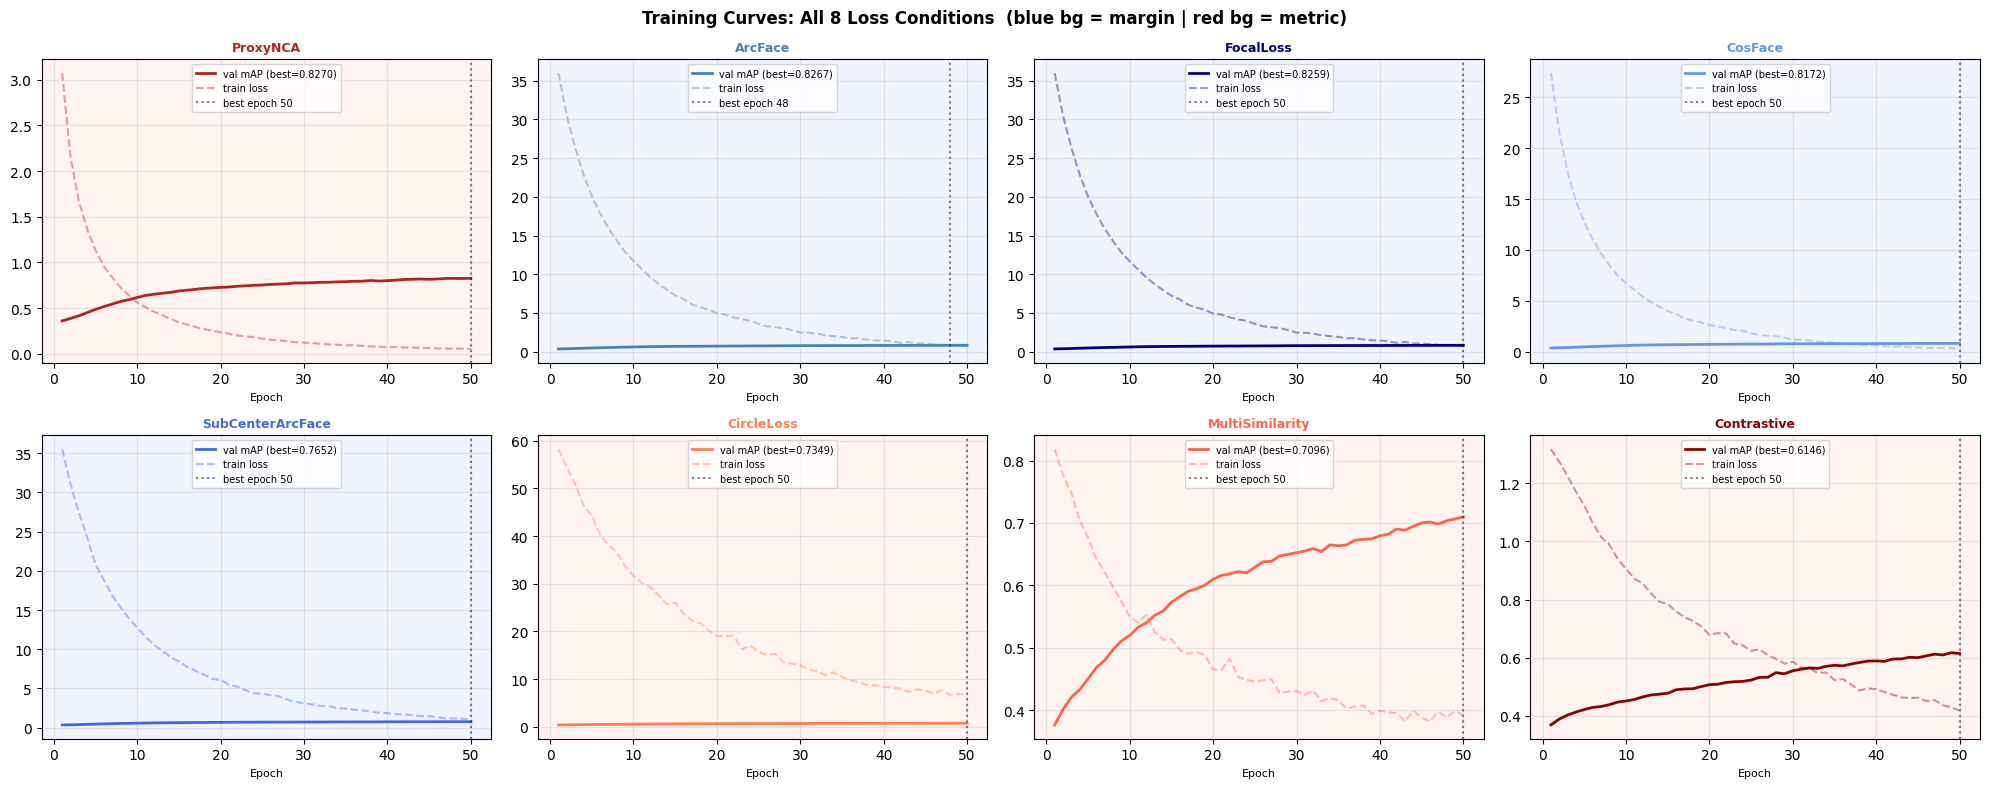

In [40]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharex=False)
axes = axes.flat

for ax, (name, r) in zip(axes, sorted_results):
    h      = r['history']
    epochs = range(1, len(h['val_map']) + 1)
    ax.plot(epochs, h['val_map'],    color=r['color'], linewidth=2,
            label=f"val mAP (best={r['best_map']:.4f})")
    ax.plot(epochs, h['train_loss'], color=r['color'], linestyle='--',
            alpha=0.4, label='train loss')
    ax.axvline(x=r['best_epoch'], color='black', linestyle=':',
               alpha=0.5, label=f"best epoch {r['best_epoch']}")
    ax.set_title(name.replace('_', ' ')[3:], fontsize=9, fontweight='bold',
                 color=r['color'])
    ax.set_xlabel('Epoch', fontsize=8)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    # Background colour by family
    ax.set_facecolor('#f0f4ff' if r['family'] == 'classification' else '#fff4f0')

plt.suptitle('Training Curves: All 8 Loss Conditions  '
             '(blue bg = margin | red bg = metric)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
wandb.log({"results/training_curves": wandb.Image(fig)})
plt.savefig(config['checkpoint_dir'] / 'training_curves_all.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 10. Per-Identity Analysis

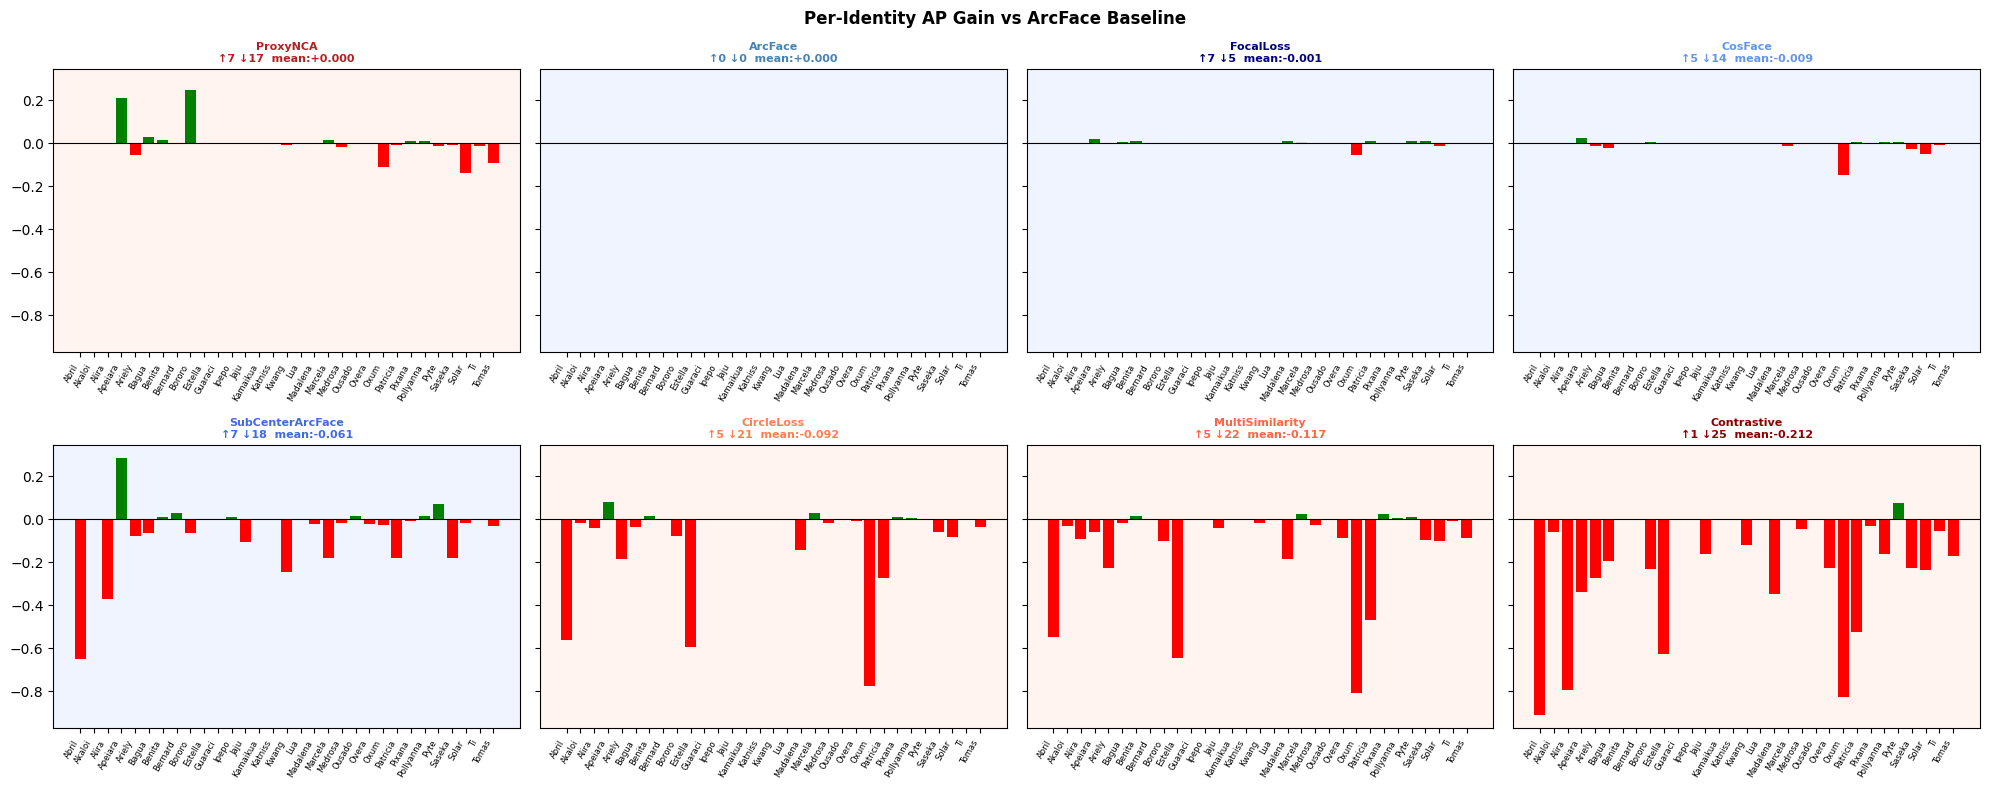

In [41]:
# Compare every loss vs ArcFace baseline
baseline_name   = "01_ArcFace"
baseline_per_id = all_results[baseline_name]['per_id_ap']
identities      = sorted(baseline_per_id.keys())

fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharey=True)
axes = axes.flat

for ax, (name, r) in zip(axes, sorted_results):
    gains  = [r['per_id_ap'].get(i, 0) - baseline_per_id.get(i, 0)
              for i in identities]
    colors_bar = ['green' if g > 0.001 else 'red' if g < -0.001
                  else 'lightgray' for g in gains]
    ax.bar(range(len(identities)), gains, color=colors_bar)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(range(len(identities)))
    ax.set_xticklabels(identities, rotation=60, ha='right', fontsize=6)
    n_imp = sum(1 for g in gains if g > 0.001)
    n_hrt = sum(1 for g in gains if g < -0.001)
    ax.set_title(f"{name[3:].replace('_',' ')}\n"
                 f"↑{n_imp} ↓{n_hrt}  mean:{np.mean(gains):+.3f}",
                 fontsize=8, fontweight='bold', color=r['color'])
    ax.set_facecolor('#f0f4ff' if r['family'] == 'classification' else '#fff4f0')

plt.suptitle('Per-Identity AP Gain vs ArcFace Baseline',
             fontsize=12, fontweight='bold')
plt.tight_layout()
wandb.log({"results/per_identity_gains": wandb.Image(fig)})
plt.show()


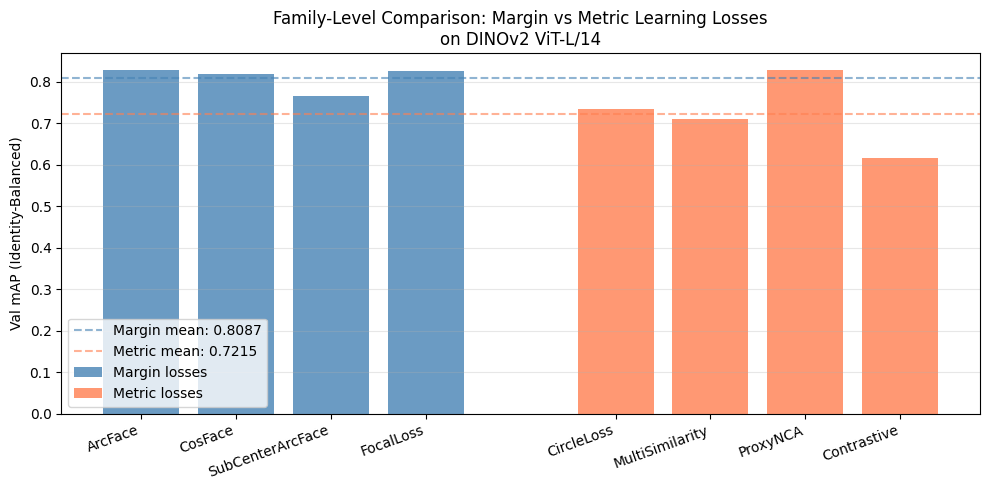

Family comparison:
  Mean margin loss mAP: 0.8087
  Mean metric loss mAP: 0.7215
  Metric advantage:     -0.0872

Interpretation:
  ✓ Classification-margin losses outperform metric learning losses —
    the structured class-centre geometry from ArcFace-family losses
    provides better inductive bias for the small jaguar dataset.


In [42]:
# Mean per-identity AP across all identities for each loss
fig, ax = plt.subplots(figsize=(10, 5))
margin_maps = [(n, r['best_map']) for n, r in all_results.items()
               if r['family'] == 'classification']
metric_maps = [(n, r['best_map']) for n, r in all_results.items()
               if r['family'] == 'metric']

x_margin = np.arange(len(margin_maps))
x_metric  = np.arange(len(metric_maps)) + len(margin_maps) + 1

ax.bar(x_margin, [m for _, m in margin_maps],
       color='steelblue', alpha=0.8, label='Margin losses')
ax.bar(x_metric,  [m for _, m in metric_maps],
       color='coral',    alpha=0.8, label='Metric losses')

all_x = list(x_margin) + list(x_metric)
all_names = [n[3:].replace('_',' ') for n, _ in margin_maps + metric_maps]
ax.set_xticks(all_x); ax.set_xticklabels(all_names, rotation=20, ha='right')

# Family means
mean_margin = np.mean([m for _, m in margin_maps])
mean_metric  = np.mean([m for _, m in metric_maps])
ax.axhline(mean_margin, color='steelblue', linestyle='--', alpha=0.6,
           label=f'Margin mean: {mean_margin:.4f}')
ax.axhline(mean_metric, color='coral', linestyle='--', alpha=0.6,
           label=f'Metric mean: {mean_metric:.4f}')

ax.set_ylabel('Val mAP (Identity-Balanced)')
ax.set_title('Family-Level Comparison: Margin vs Metric Learning Losses\n'
             'on DINOv2 ViT-L/14')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
wandb.log({"results/family_comparison": wandb.Image(fig)})
plt.show()

print(f"Family comparison:")
print(f"  Mean margin loss mAP: {mean_margin:.4f}")
print(f"  Mean metric loss mAP: {mean_metric:.4f}")
print(f"  Metric advantage:     {mean_metric - mean_margin:+.4f}")
print(f"\nInterpretation:")
if mean_metric > mean_margin:
    print("  ✓ Metric learning losses outperform classification-margin losses")
    print("    on average — direct pairwise optimisation fits jaguar re-ID better")
    print("    than treating it as N-class classification.")
else:
    print("  ✓ Classification-margin losses outperform metric learning losses —")
    print("    the structured class-centre geometry from ArcFace-family losses")
    print("    provides better inductive bias for the small jaguar dataset.")

wandb.log({
    "results/mean_margin_map": mean_margin,
    "results/mean_metric_map": mean_metric,
    "results/metric_advantage": mean_metric - mean_margin,
})


## 11. Generate Competition Submission

In [43]:
test_pairs_df = pd.read_csv(config["data_dir"] / "test.csv")
test_images   = sorted(
    set(test_pairs_df['query_image'].unique()) |
    set(test_pairs_df['gallery_image'].unique()))
test_paths = [config["data_dir"] / "test/test" / fn for fn in test_images]

print(f"Test pairs:    {len(test_pairs_df)}")
print(f"Test images:   {len(test_images)}")
print(f"Best loss:     {best_name}  (mAP={best_r['best_map']:.4f})")

# Extract DINOv2 test embeddings
te_cache = config["cache_dir"] / "dinov2_test_embeddings.npz"
if te_cache.exists():
    test_backbone_embs = np.load(te_cache)["embeddings"]
    print(f"Loaded cached test embeddings: {test_backbone_embs.shape}")
else:
    print("Extracting DINOv2 test embeddings...")
    test_backbone_embs = extract_embeddings(
        dinov2, test_paths, config["batch_size"], "DINOv2 test")
    np.savez_compressed(te_cache, embeddings=test_backbone_embs)
    print(f"Saved: {test_backbone_embs.shape}")

# Reload best projection head
best_ckpt  = torch.load(
    config["checkpoint_dir"] / f"{best_name}_best.pth",
    map_location=device, weights_only=False)
best_proj  = EmbeddingProjection(
    best_ckpt['dinov2_dim'], config["hidden_dim"],
    config["embedding_dim"], config["dropout"]).to(device)
best_proj.load_state_dict(best_ckpt['proj_state'])
best_proj.eval()

with torch.no_grad():
    test_emb = best_proj.get_embeddings(
        torch.FloatTensor(test_backbone_embs).to(device)).cpu().numpy()
test_emb   = test_emb / (np.linalg.norm(test_emb, axis=1, keepdims=True) + 1e-12)
img_to_emb = dict(zip(test_images, test_emb))
print(f"Test embeddings projected: {test_emb.shape}")


Test pairs:    137270
Test images:   371
Best loss:     07_ProxyNCA  (mAP=0.8270)
Loaded cached test embeddings: (371, 1024)
Test embeddings projected: (371, 256)


In [44]:
similarities = []
for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df),
                   desc="Computing similarities"):
    q = img_to_emb[row['query_image']]
    g = img_to_emb[row['gallery_image']]
    similarities.append(float(np.dot(q, g)))

similarities   = np.clip(np.array(similarities), 0.0, 1.0)
submission_df  = pd.DataFrame({'row_id':     test_pairs_df['row_id'],
                                'similarity': similarities})
submission_path = config['checkpoint_dir'] / 'submission.csv'
submission_df.to_csv(submission_path, index=False)
submission_df.to_csv('/kaggle/working/submission.csv', index=False)
print(f"Submission saved: {submission_path}")
print(f"  Sim stats: min={similarities.min():.4f}  "
      f"max={similarities.max():.4f}  mean={similarities.mean():.4f}")
print(submission_df.head(10))


Computing similarities:   0%|          | 0/137270 [00:00<?, ?it/s]

Submission saved: /kaggle/working/checkpoints/submission.csv
  Sim stats: min=0.0000  max=0.9950  mean=0.0725
   row_id  similarity
0       0    0.760010
1       1    0.098537
2       2    0.137300
3       3    0.223516
4       4    0.084894
5       5    0.233116
6       6    0.000000
7       7    0.000000
8       8    0.204748
9       9    0.162272


## 12. Save Artifacts to W&B

In [45]:
# Full results table
rows = []
for name, r in sorted_results:
    rows.append({
        "loss":        name,
        "family":      r['family'],
        "val_map":     round(r['best_map'], 6),
        "best_epoch":  r['best_epoch'],
        "description": r['description'],
    })
wandb.log({"results/all_losses_table": wandb.Table(
    dataframe=pd.DataFrame(rows))})

# Best checkpoint artifact
art = wandb.Artifact("loss-comparison-dinov2-best", type="model",
    description=f"Best: {best_name} (mAP={best_r['best_map']:.4f})")
art.add_file(str(config['checkpoint_dir'] / f'{best_name}_best.pth'))
wandb.log_artifact(art)

# Submission artifact
sub_art = wandb.Artifact("submission", type="submission",
    description=f"Loss comparison | best={best_name}")
sub_art.add_file(str(submission_path))
wandb.log_artifact(sub_art)

wandb.finish()
print("W&B run completed.")
print(f"Best checkpoint: {config['checkpoint_dir'] / f'{best_name}_best.pth'}")


01_ArcFace/best_epoch,▁
01_ArcFace/best_val_map,▁
01_ArcFace/epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
01_ArcFace/lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
01_ArcFace/train_loss,█▇▆▅▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
01_ArcFace/val_loss,█▇▆▅▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
01_ArcFace/val_map,▁▁▂▃▃▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█████████████
02_CosFace/best_epoch,▁
02_CosFace/best_val_map,▁
02_CosFace/epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
+56,...


W&B run completed.
Best checkpoint: /kaggle/working/checkpoints/07_ProxyNCA_best.pth
